In [16]:
import numpy as np
import torch
import cv2 as cv
import glob
import os
import matplotlib.pyplot as plt
from model import RoboBlockNet, BlocksDataset
from model_utils import *
# from google.colab.patches import cv2_imshow

 ```py
 def forward(self, imgs, size=640, augment=False, profile=False): 
     # Inference from various sources. For height=640, width=1280, RGB images example inputs are: 
     #   filename:   imgs = 'data/images/zidane.jpg' 
     #   URI:             = 'https://github.com/ultralytics/yolov5/releases/download/v1.0/zidane.jpg' 
     #   OpenCV:          = cv2.imread('image.jpg')[:,:,::-1]  # HWC BGR to RGB x(640,1280,3) 
     #   PIL:             = Image.open('image.jpg')  # HWC x(640,1280,3) 
     #   numpy:           = np.zeros((640,1280,3))  # HWC 
     #   torch:           = torch.zeros(16,3,320,640)  # BCHW (scaled to size=640, 0-1 values) 
     #   multiple:        = [Image.open('image1.jpg'), Image.open('image2.jpg'), ...]  # list of images 
```

Class for loading labelled data for presentation to the NN

The Neural Network architecture

Test & Train Datasets


In [2]:
train_dataset = BlocksDataset(f"{TRAIN_DATA_DIR}/test_images", f"{TRAIN_DATA_DIR}/segmentations")
test_dataset = BlocksDataset(f"{TEST_DATA_DIR}/test_images", f"{TEST_DATA_DIR}/segmentations")
train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=4, shuffle=True)#, num_workers=4)
test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=1, shuffle=True)#, num_workers=4)

Instantiate the model & send to the GPU

In [3]:
if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print(f"Training on: {device}")

model = RoboBlockNet().to(device)
model

Training on: mps


RoboBlockNet(
  (backbone): FCN(
    (backbone): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (

In [5]:
weights = [1] # for black pixel
for i in range(NUM_CLASSES):
    weights.append(250)
weights, len(weights)

([1,
  250,
  250,
  250,
  250,
  250,
  250,
  250,
  250,
  250,
  250,
  250,
  250,
  250,
  250,
  250,
  250,
  250,
  250,
  250,
  250,
  250,
  250,
  250,
  250],
 25)

Perform Training

In [6]:
# 2. Loss and Optimizer
weights = torch.Tensor(weights).to(device)
loss_fn = torch.nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# 3. Training Loop
num_epochs = 20
model.train()

for epoch in range(num_epochs):
    epoch_loss = 0
    for batch in train_dataloader:
        input_img = batch['rgb_sized'].to(device)
        output_gt = batch['segmentation_sized'].squeeze(1).to(device).long() # Ensure Long type
        
        # Forward
        output_pred = model(input_img)
        batch_loss = loss_fn(output_pred, output_gt)
        
        # Backward
        optimizer.zero_grad()
        batch_loss.backward()
        optimizer.step()
        
        epoch_loss += batch_loss.item()
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch} | Loss: {epoch_loss/len(train_dataloader):.4f}")

Epoch 0 | Loss: 2.9040
Epoch 10 | Loss: 0.7455


KeyboardInterrupt: 

In [7]:
# After output_pred = model(input_img)
unique_preds = torch.unique(torch.argmax(output_pred, dim=1))
print(f"Model is predicting classes: {unique_preds.tolist()}")

Model is predicting classes: [0, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 13, 14, 15, 17, 18, 19, 20, 21, 22]


Check output against a training dataset ground truth

In [8]:
# 4. Evaluation Loop (Fixed .cuda() error)
model.eval()
outputs = []
gts = []

with torch.no_grad(): # Saves memory/time by not tracking gradients
    for batch in train_dataloader:
        # Use .to(device) instead of .cuda()
        input_img = batch['rgb_sized'].to(device)
        
        # Get prediction
        raw_output = model(input_img)
        output_tensor = torch.argmax(raw_output, dim=1)
        
        # Move back to CPU for storage/plotting
        outputs.append(output_tensor.squeeze(0).cpu())
        gts.append(batch['segmentation_sized'].squeeze().cpu())

print("Evaluation complete. Results stored in 'outputs' and 'gts'.")

Evaluation complete. Results stored in 'outputs' and 'gts'.


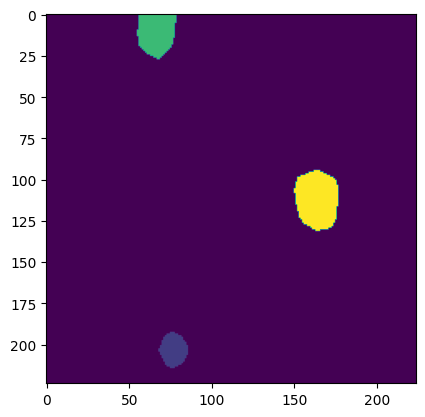

In [9]:
plt.imshow(outputs[1][0].cpu().numpy() * 255/NUM_CLASSES)
plt.show()

In [ ]:
# test = gts[0].cpu().numpy()
# print(test.shape)
# plt.imshow(gts[0].cpu().numpy() * 255/NUM_CLASSES, cmap='gray')
# plt.show()

Check Output against a new image (test dataset) ground truth

In [10]:
model.eval()
outputs = []
gts = []
for batch in iter(test_dataloader):
  input_img = batch['rgb_sized'].to(device)
  output_tensor = torch.argmax(model(input_img),1)
  outputs.append(output_tensor.squeeze(0))
  gts.append(batch['segmentation_sized'].squeeze().to(device))

/var/folders/sn/wstp0w017s1b5by7yvfp07tm0000gn/T/ipykernel_11214/2523818826.py:3: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  img_pair = np.row_stack((output_pair, gt_pair))


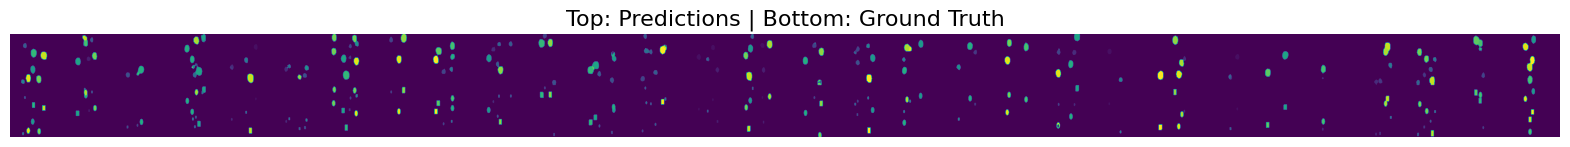

In [11]:
output_pair = np.concatenate([output.cpu().numpy() for output in outputs], axis=1)
gt_pair = np.concatenate([gt.cpu().numpy() for gt in gts], axis=1)
img_pair = np.row_stack((output_pair, gt_pair))
plt.figure(figsize=(20, 10)) 
plt.imshow(img_pair * 255/NUM_CLASSES)
plt.axis('off')
plt.title("Top: Predictions | Bottom: Ground Truth", fontsize=16)
plt.show()

In [12]:
model_path = "model_fcn_re101_cpu_402.pth"
torch.save(model, model_path)

In [ ]:
# plt.imshow(gts[0].cpu().numpy() * 255/NUM_CLASSES, cmap='gray')
# plt.show()

In [13]:
model_test = torch.load(model_path, weights_only=False)
model_test.eval()
outputs = []
gts = []
for batch in iter(test_dataloader):
  input_img = batch['rgb_sized'].to(device)
  output_tensor = torch.argmax(model_test(input_img),1)
  outputs.append(output_tensor.squeeze(0))
  gts.append(batch['segmentation_sized'].squeeze().to(device))

/var/folders/sn/wstp0w017s1b5by7yvfp07tm0000gn/T/ipykernel_11214/2523818826.py:3: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  img_pair = np.row_stack((output_pair, gt_pair))


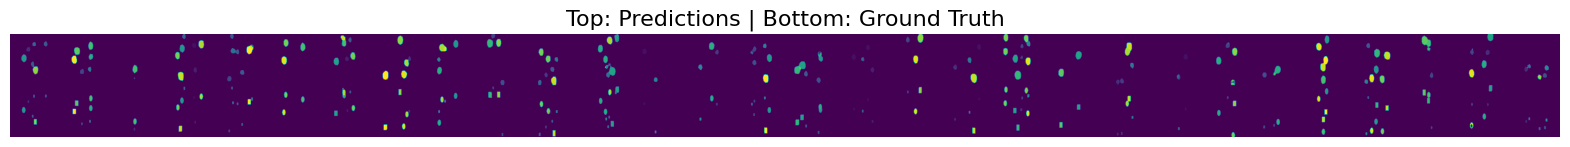

In [14]:
output_pair = np.concatenate([output.cpu().numpy() for output in outputs], axis=1)
gt_pair = np.concatenate([gt.cpu().numpy() for gt in gts], axis=1)
img_pair = np.row_stack((output_pair, gt_pair))
plt.figure(figsize=(20, 10)) 
plt.imshow(img_pair * 255/NUM_CLASSES)
plt.axis('off')
plt.title("Top: Predictions | Bottom: Ground Truth", fontsize=16)
plt.show()

In [15]:
# get green block, record time: ~3-4 sec
# 1. Run the model (Inference)
import time
start_time = time.perf_counter()
img = batch['rgb_sized'].squeeze(0) # Get the single input image from the batch
model_test.eval()
with torch.no_grad():
    # Assume 'img' is a single input image [3, 224, 224]
    output = model_test(img.unsqueeze(0).to(device)) 
    pred_mask = torch.argmax(output, dim=1).squeeze(0).cpu().numpy()

# 2. Identify the Green Class ID
# Based on your weights [1, 250, 250...], if Green is the 4th block:
GREEN_ID = 4

# 3. Create the specific "Green Only" Mask
green_mask = (pred_mask == GREEN_ID).astype(np.uint8)

# 4. Visualize it
# plt.figure(figsize=(10, 5))
# plt.subplot(1, 2, 1)
# plt.imshow(img.permute(1, 2, 0).cpu().numpy()) # Original Image
# plt.title("Original")

# plt.subplot(1, 2, 2)
# plt.imshow(green_mask, cmap='Greens') # Shows only the green block
# plt.title("Detected Green Block")
# plt.show()
end_time = time.perf_counter()
elapsed = end_time - start_time

print(f"Time elapsed: {elapsed:.4f} seconds")

Time elapsed: 1.2635 seconds
